In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("cs-training.csv")
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,150000.0,75000.500000,43301.414527,1.0,37500.750000,75000.500000,112500.250000,150000.0
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0


In [9]:
df.isnull().sum()

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [11]:
df = df.drop("Unnamed: 0", axis=1)

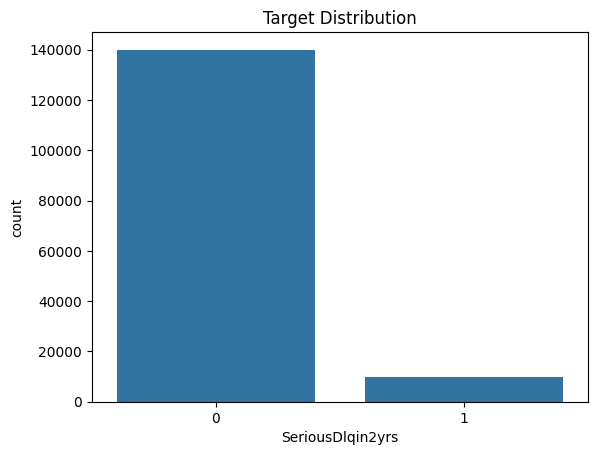

In [14]:
ax = sns.countplot(data=df, x = "SeriousDlqin2yrs")
ax.set_title("Target Distribution")
plt.show()

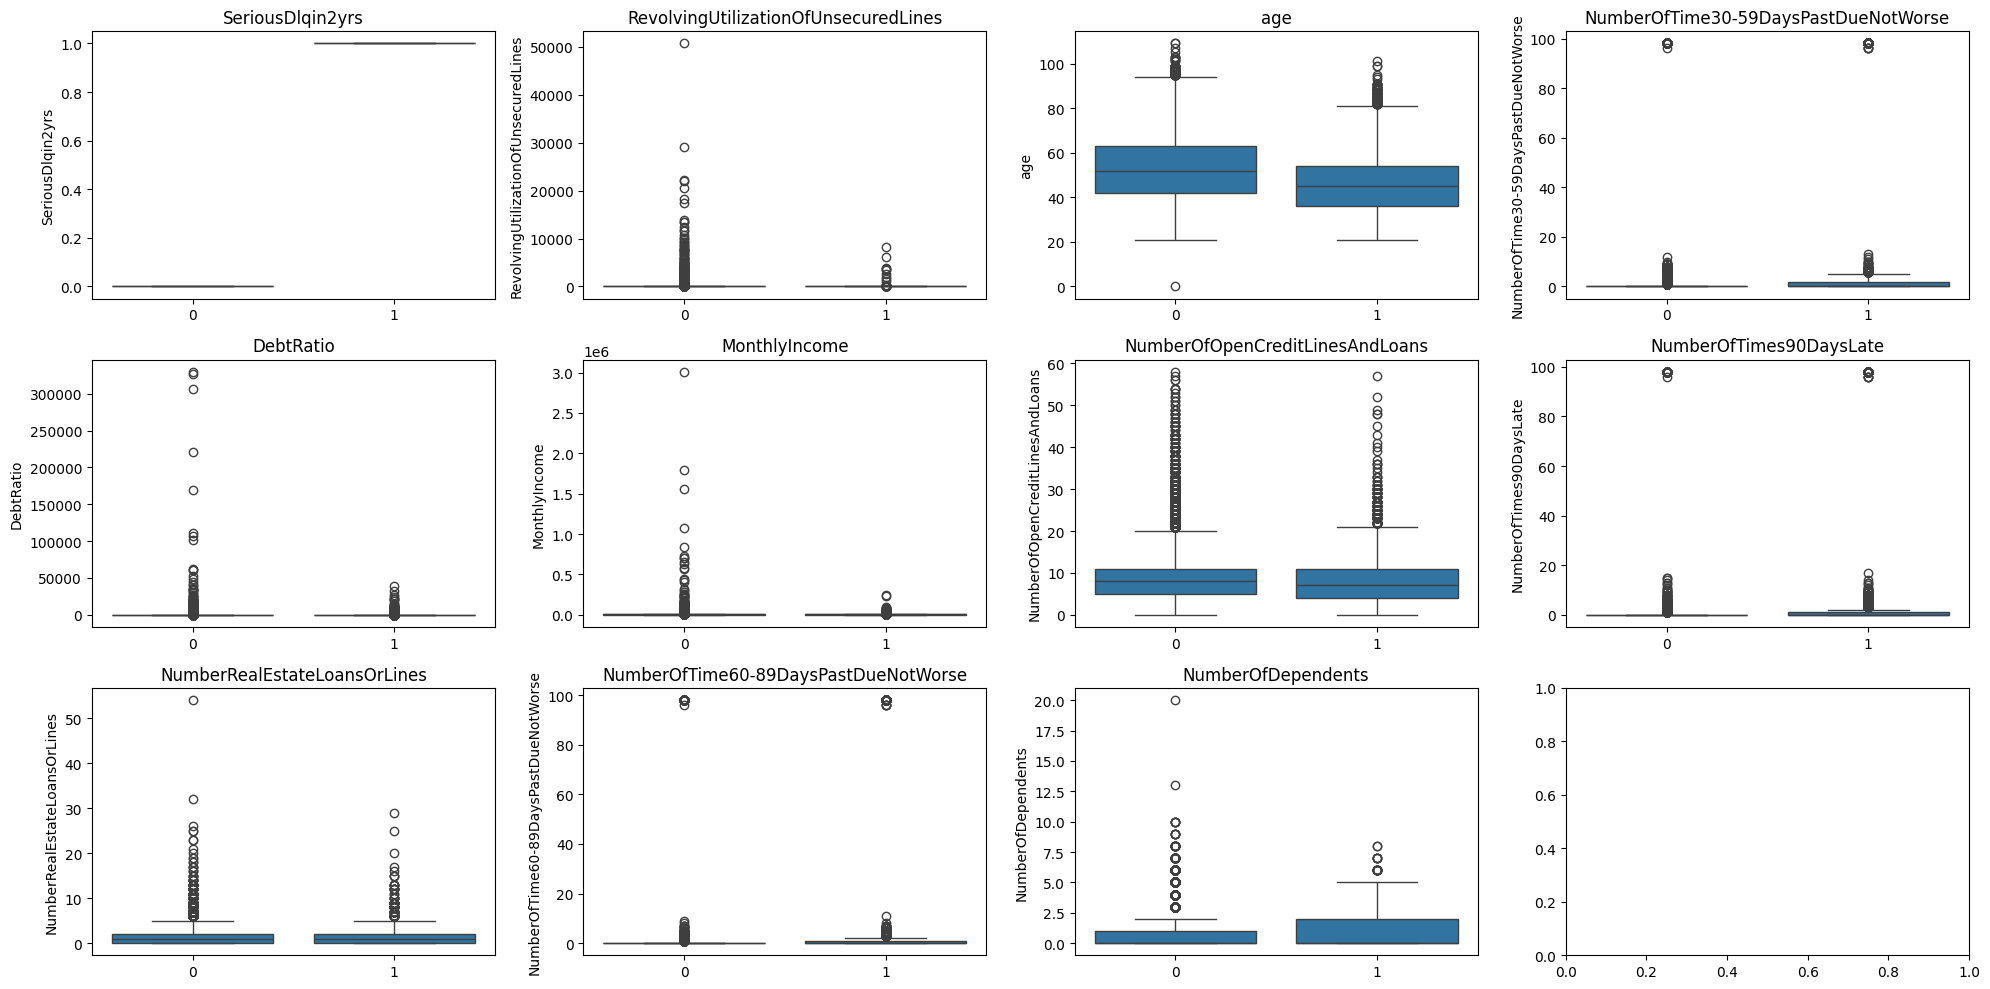

In [18]:
fig, axes = plt.subplots(3, 4, figsize=(20, 10))
for ax, col in zip(axes.ravel(), df):
    sns.boxplot(data=df, x="SeriousDlqin2yrs", y=col, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

In [19]:
def clean_data(df, bounds):
    
    df = df.copy()
    for col, (lo, hi) in bounds.items():
        if col not in df.columns:
            continue
        if lo is not None:
            df.loc[df[col] < lo, col] = np.nan
        if hi is not None:
            df.loc[df[col] > hi, col] = np.nan
    return df

In [20]:
BOUNDS = {
    "age": (18, 110),                                  
    "NumberOfTime30-59DaysPastDueNotWorse": (0, 50),   
    "NumberOfTime60-89DaysPastDueNotWorse": (0, 50),
    "NumberOfTimes90DaysLate": (0, 50),
}

df = clean_data(df, BOUNDS)

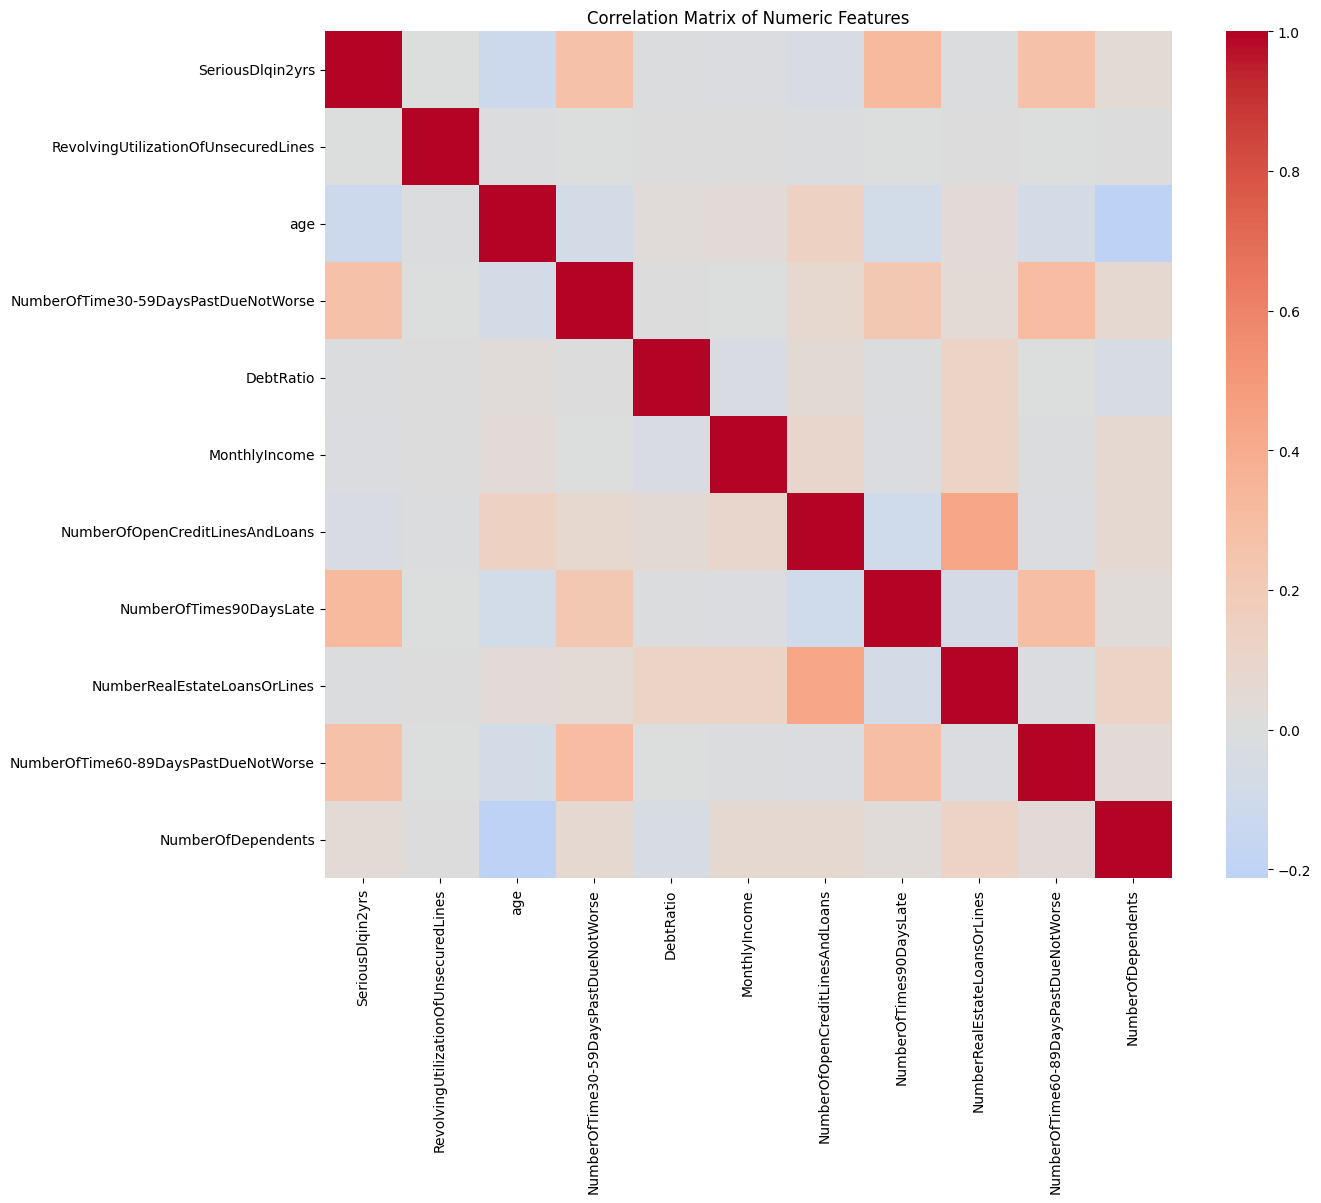

In [21]:
corr = df.corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, square=True)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

In [32]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)

In [30]:
X = df.drop(columns=["SeriousDlqin2yrs"])
y = df["SeriousDlqin2yrs"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)

In [35]:
gb = XGBClassifier(random_state=42, eval_metric="auc")
gb.fit(X_train, y_train)
y_pred_gb  = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:, 1]

print(f"AUC:      {roc_auc_score(y_test, y_proba_gb):.4f}")
print(f"\n{classification_report(y_test, y_pred_gb, digits=3)}")

AUC:      0.8604

              precision    recall  f1-score   support

           0      0.946     0.988     0.966     27995
           1      0.549     0.205     0.298      2005

    accuracy                          0.936     30000
   macro avg      0.747     0.596     0.632     30000
weighted avg      0.919     0.936     0.922     30000



In [41]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(gb, X, y, cv=cv, scoring="roc_auc")

print(f"CV AUC: {scores.mean():.4f} ± {scores.std():.4f}")

CV AUC: 0.8566 ± 0.0043


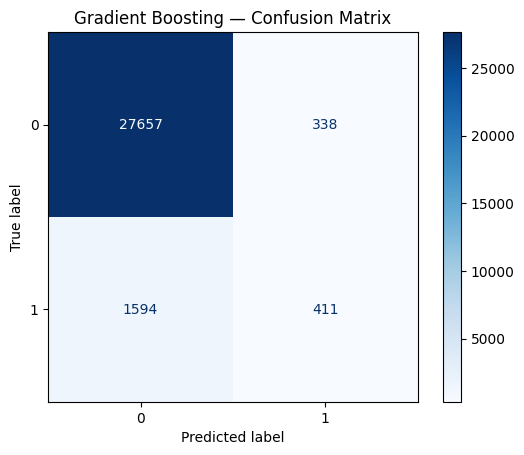

In [40]:
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_gb),
    display_labels=["0", "1"]
).plot(cmap="Blues")
plt.title("Gradient Boosting — Confusion Matrix")
plt.show()